*Aprendizaje Profundo*  
*Proyecto -* Detector de Vehiculos  
*Autores:* Ing. Daniel González & Ing. Michael Guerra  
*Profesor:* Dr. Sebastian Salazar

# Librerias

In [54]:
import os
import numpy as np
import tensorflow as tf
import random
from tensorflow import keras
from tensorflow.keras import layers, models, regularizers
from tensorflow.keras.utils import load_img, img_to_array
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.utils.class_weight import compute_class_weight
import seaborn as sns

from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input


# Database

In [26]:
base_dir = r".\\DB\\Cars_Detection"

train_img_dir = os.path.join(base_dir, "train", "images")
train_lbl_dir = os.path.join(base_dir, "train", "labels")

val_img_dir   = os.path.join(base_dir, "valid", "images")
val_lbl_dir   = os.path.join(base_dir, "valid", "labels")

print("Train images:", train_img_dir)
print("Valid images:", val_img_dir)

Train images: .\\DB\\Cars_Detection\train\images
Valid images: .\\DB\\Cars_Detection\valid\images


# Clases

In [27]:
class_names = ['Ambulance', 'Bus', 'Car', 'Motorcycle', 'Truck']
num_classes = len(class_names)

## Cargar Imagenes con su etiqueta de clase

In [28]:
img_size = (224, 224)

def load_split(img_dir, lbl_dir):
    X = []
    y = []

    image_files = [f for f in os.listdir(img_dir) 
                   if f.lower().endswith((".jpg", ".jpeg", ".png", ".bmp"))]

    for fname in image_files:
        img_path = os.path.join(img_dir, fname)
        label_path = os.path.join(lbl_dir, os.path.splitext(fname)[0] + ".txt")

        # cargar imagen
        img = load_img(img_path, target_size=img_size)
        img_array = img_to_array(img) / 255.0

        # leer primer id de clase
        with open(label_path, "r") as f:
            line = f.readline().strip()
        if not line:
            continue
        parts = line.split()
        class_id = int(parts[0])

        X.append(img_array)
        y.append(class_id)

    X = np.array(X, dtype="float32")
    y = np.array(y, dtype="int32")
    return X, y

X_train, y_train = load_split(train_img_dir, train_lbl_dir)
X_val,   y_val   = load_split(val_img_dir,   val_lbl_dir)

print("Train shape:", X_train.shape, y_train.shape)
print("Val shape:",   X_val.shape,   y_val.shape)


Train shape: (878, 224, 224, 3) (878,)
Val shape: (250, 224, 224, 3) (250,)


# Balanceo

In [29]:
classes = np.arange(num_classes)

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train
)

class_weight_dict = {i: w for i, w in enumerate(class_weights)}
print("class_weight:", class_weight_dict)


class_weight: {0: np.float64(1.488135593220339), 1: np.float64(1.2911764705882354), 2: np.float64(0.4771739130434783), 3: np.float64(1.3936507936507936), 4: np.float64(1.3507692307692307)}


# CNN

In [30]:
model = models.Sequential([
    layers.Input(shape=img_size + (3,)),

    layers.Conv2D(32, (3,3), activation="relu"),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation="relu"),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(128, (3,3), activation="relu"),
    layers.MaxPooling2D((2,2)),

    layers.Flatten(),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.5),
    layers.Dense(num_classes, activation="softmax")
])

model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,605 (42.61 MB)

 Trainable params: 11,169,605 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

# Compilar y Entrenar

In [31]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=10,
    batch_size=32,
    shuffle=True,
    class_weight=class_weight_dict
)

Epoch 1/10
28/28 ━━━━━━━━━━━━━━━━━━━━ 10s 323ms/step - accuracy: 0.2157 - loss: 2.1098 - val_accuracy: 0.1680 - val_loss: 1.5783
Epoch 2/10
28/28 ━━━━━━━━━━━━━━━━━━━━ 9s 320ms/step - accuracy: 0.3949 - loss: 1.5367 - val_accuracy: 0.2480 - val_loss: 1.5884
Epoch 3/10
28/28 ━━━━━━━━━━━━━━━━━━━━ 9s 314ms/step - accuracy: 0.4925 - loss: 1.1980 - val_accuracy: 0.3360 - val_loss: 1.6079
Epoch 4/10
28/28 ━━━━━━━━━━━━━━━━━━━━ 9s 318ms/step - accuracy: 0.7379 - loss: 0.6120 - val_accuracy: 0.4080 - val_loss: 2.0669
Epoch 5/10
28/28 ━━━━━━━━━━━━━━━━━━━━ 9s 320ms/step - accuracy: 0.9001 - loss: 0.2614 - val_accuracy: 0.3360 - val_loss: 2.9650
Epoch 6/10
28/28 ━━━━━━━━━━━━━━━━━━━━ 9s 316ms/step - accuracy: 0.9497 - loss: 0.1308 - val_accuracy: 0.4480 - val_loss: 3.2012
Epoch 7/10
28/28 ━━━━━━━━━━━━━━━━━━━━ 9s 320ms/step - accuracy: 0.9498 - loss: 0.1260 - val_accuracy: 0.3920 - val_loss: 3.1181
Epoch 8/10
28/28 ━━━━━━━━━━━━━━━━━━━━ 9s 319ms/step - accuracy: 0.9796 - loss: 0.0833 - val_accuracy: 0

# Metricas

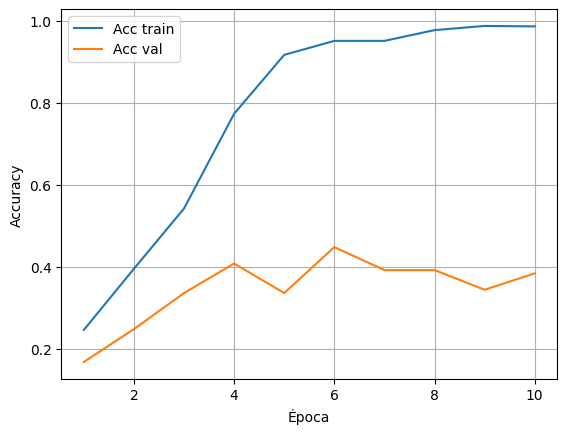

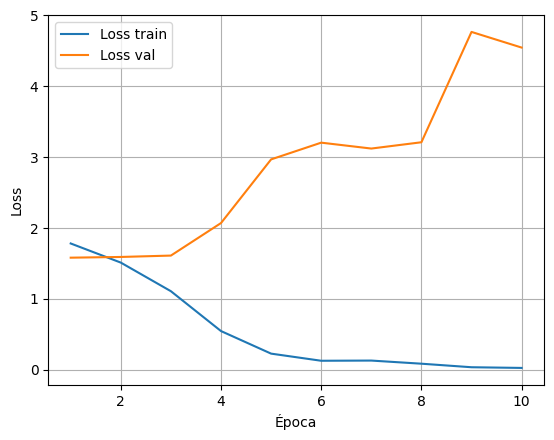

In [32]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs_range = range(1, len(acc) + 1)

plt.figure()
plt.plot(epochs_range, acc, label="Acc train")
plt.plot(epochs_range, val_acc, label="Acc val")
plt.legend()
plt.xlabel("Época")
plt.ylabel("Accuracy")
plt.grid(True)
plt.show()

plt.figure()
plt.plot(epochs_range, loss, label="Loss train")
plt.plot(epochs_range, val_loss, label="Loss val")
plt.legend()
plt.xlabel("Época")
plt.ylabel("Loss")
plt.grid(True)
plt.show()


# Test

In [33]:
test_img_dir = os.path.join(base_dir, "test", "images")
test_lbl_dir = os.path.join(base_dir, "test", "labels")

X_test, y_test = load_split(test_img_dir, test_lbl_dir)

print("Test shape:", X_test.shape, y_test.shape)

Test shape: (126, 224, 224, 3) (126,)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step


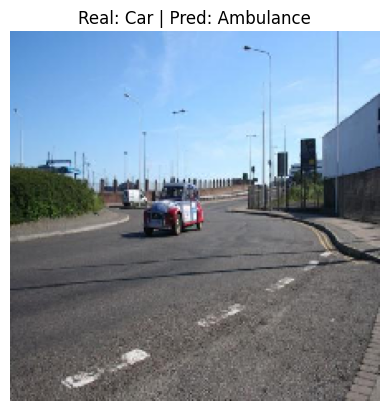

Probabilidades: [0.79295003 0.03488661 0.10615585 0.00777415 0.05823334]
Clases ['Ambulance', 'Bus', 'Car', 'Motorcycle', 'Truck']


In [41]:
idx = random.randint(0, len(X_test)-1)
img = X_test[idx]
true_label = class_names[y_test[idx]]

pred = model.predict(img[np.newaxis, ...])
pred_id = np.argmax(pred[0])
pred_label = class_names[pred_id]

plt.imshow(img)
plt.axis("off")
plt.title(f"Real: {true_label} | Pred: {pred_label}")
plt.show()

print("Probabilidades:", pred[0])
print("Clases", class_names)

# Matriz de confusión

In [42]:
y_pred_probs = model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step


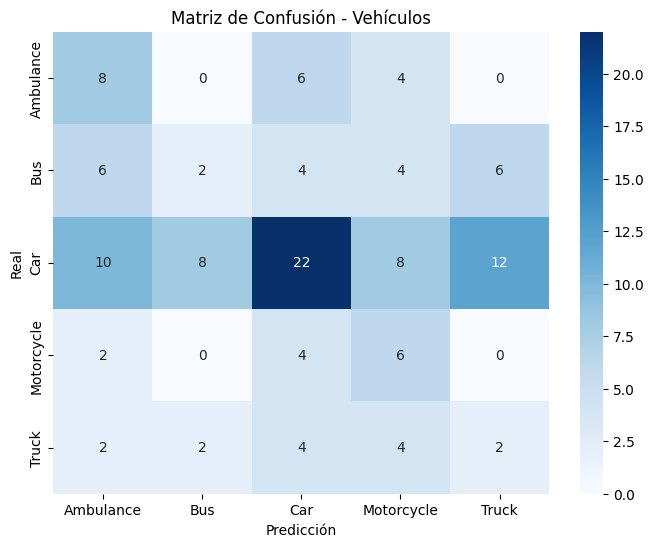

In [43]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.title("Matriz de Confusión - Vehículos")
plt.show()



# Guardar Modelo

In [ ]:
#model.save(".\\modelos\\cnn_vehiculos_simple.keras")

# Cargar Modelo

In [ ]:
#model = models.load_model(".\\modelos\\cnn_vehiculos_simple.keras")

# Transfer Learning

In [46]:
data_augmentation = keras.Sequential(
    [
        layers.RandomFlip("horizontal"),
        layers.RandomRotation(0.1),
        layers.RandomZoom(0.1),
    ],
    name="data_augmentation"
)


In [47]:
img_shape = X_train.shape[1:]

base_model = MobileNetV2(
    input_shape=img_shape,
    include_top=False,
    weights="imagenet"
)

base_model.trainable = False  # congelamos el modelo base

base_model.summary()


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "mobilenetv2_1.00_224"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_4       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer_4[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,257,984 (8.61 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 2,257,984 (8.61 MB)

# Modelo con TL

In [48]:
inputs = keras.Input(shape=img_shape)
x = data_augmentation(inputs)

# Escalamos a 0–255 y aplicamos preprocess_input de MobileNetV2
x = layers.Lambda(lambda img: preprocess_input(img * 255.0))(x)

# Pasamos por la red base preentrenada
x = base_model(x, training=False)

x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(num_classes, activation="softmax")(x)

model_tl = keras.Model(inputs, outputs, name="vehiculos_mobilenetv2")
model_tl.summary()

Model: "vehiculos_mobilenetv2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lambda (Lambda)                 │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 5)              │         6,405 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,264,389 (8.64 MB)

 Trainable params: 6,405 (25.02 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

# Compilar y Entrenar

In [49]:
model_tl.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

epochs = 15

history_tl = model_tl.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=epochs,
    batch_size=32,
    shuffle=True,
    callbacks=[early_stop]
)


Epoch 1/15
28/28 ━━━━━━━━━━━━━━━━━━━━ 15s 427ms/step - accuracy: 0.3575 - loss: 1.6426 - val_accuracy: 0.6800 - val_loss: 0.8436
Epoch 2/15
28/28 ━━━━━━━━━━━━━━━━━━━━ 11s 376ms/step - accuracy: 0.6592 - loss: 0.9578 - val_accuracy: 0.7760 - val_loss: 0.6606
Epoch 3/15
28/28 ━━━━━━━━━━━━━━━━━━━━ 11s 382ms/step - accuracy: 0.7114 - loss: 0.7648 - val_accuracy: 0.7840 - val_loss: 0.6035
Epoch 4/15
28/28 ━━━━━━━━━━━━━━━━━━━━ 11s 402ms/step - accuracy: 0.7483 - loss: 0.7103 - val_accuracy: 0.7680 - val_loss: 0.5750
Epoch 5/15
28/28 ━━━━━━━━━━━━━━━━━━━━ 10s 357ms/step - accuracy: 0.7668 - loss: 0.6047 - val_accuracy: 0.7760 - val_loss: 0.5730
Epoch 6/15
28/28 ━━━━━━━━━━━━━━━━━━━━ 10s 346ms/step - accuracy: 0.7869 - loss: 0.5654 - val_accuracy: 0.7760 - val_loss: 0.5739
Epoch 7/15
28/28 ━━━━━━━━━━━━━━━━━━━━ 10s 352ms/step - accuracy: 0.8122 - loss: 0.5207 - val_accuracy: 0.7920 - val_loss: 0.5900
Epoch 8/15
28/28 ━━━━━━━━━━━━━━━━━━━━ 10s 344ms/step - accuracy: 0.8193 - loss: 0.4482 - val_accu

# Metricas

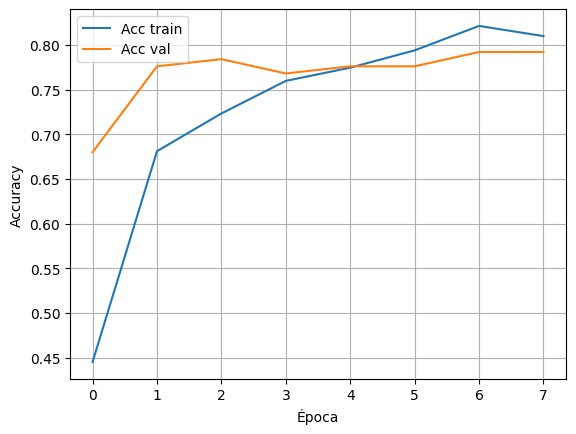

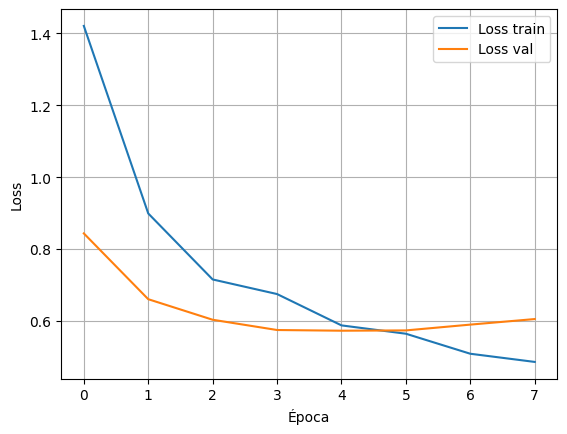

In [50]:
acc = history_tl.history['accuracy']
val_acc = history_tl.history['val_accuracy']
loss = history_tl.history['loss']
val_loss = history_tl.history['val_loss']
epochs_range = range(len(acc))

plt.figure()
plt.plot(epochs_range, acc, label='Acc train')
plt.plot(epochs_range, val_acc, label='Acc val')
plt.xlabel('Época')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

plt.figure()
plt.plot(epochs_range, loss, label='Loss train')
plt.plot(epochs_range, val_loss, label='Loss val')
plt.xlabel('Época')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()


In [51]:
test_loss, test_acc = model_tl.evaluate(X_test, y_test)
print("Accuracy en TEST (Transfer Learning):", test_acc)

4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 247ms/step - accuracy: 0.8763 - loss: 0.4361
Accuracy en TEST (Transfer Learning): 0.8730158805847168


4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 256ms/step


<Axes: >

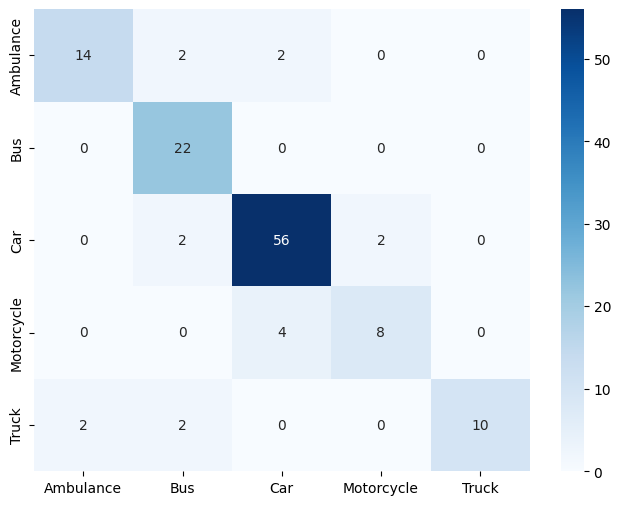

In [ ]:
y_pred_probs = model_tl.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

# Test

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step


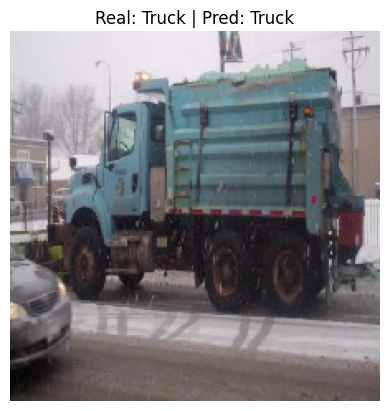

Probabilidades: [0.0302517  0.08318358 0.04522265 0.00790348 0.83343863]
Clases ['Ambulance', 'Bus', 'Car', 'Motorcycle', 'Truck']


In [63]:
idx = random.randint(0, len(X_test)-1)
img = X_test[idx]
true_label = class_names[y_test[idx]]

pred = model_tl.predict(img[np.newaxis, ...])
pred_id = np.argmax(pred[0])
pred_label = class_names[pred_id]

plt.imshow(img)
plt.axis("off")
plt.title(f"Real: {true_label} | Pred: {pred_label}")
plt.show()

print("Probabilidades:", pred[0])
print("Clases", class_names)